# 🔗 Link Prediction — Model Training & Evaluation

**Goal:** Train 8 classifiers, compare them, tune the best two, and produce
publication-ready visualisations including a post-tuning ROC comparison.

### Pipeline
| Step | Notebook |
|------|----------|
| Graph construction & EDA | `EDA.ipynb` |
| Centrality scores (Katz, HITS) | `Feature_eng.ipynb` |
| **Model training & evaluation** | **`Model_Training.ipynb` ← you are here** |

### Sections
1. Setup & Imports
2. Load Graph & Pre-computed Data
3. Rebuild Sampled DataFrames
4. Feature Engineering Functions
5. Compute Feature Matrix
6. Model Training
7. Evaluation
8. ROC Curves & Confusion Matrices — Baseline
9. Feature Importance
10. Model Comparison Summary
11. Hyperparameter Tuning (Top-2 Models)
12. ROC Curve Comparison — Baseline vs Tuned
13. Save Models
14. Inference

> **Sampling note:** The full dataset has ~30 M edges. For tractable feature
> computation we sample **100 K training pairs** and **25 K test pairs** (~0.3 % of
> total). Metrics reported reflect this sample. Model ranking is consistent across
> seeds; full-graph training would be expected to improve scores marginally.

## 1. Setup & Imports

In [1]:
import os
import math
import pickle
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

from sklearn.base            import clone
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV

import joblib

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('xgboost not installed — run: pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('lightgbm not installed — run: pip install lightgbm')

warnings.filterwarnings('ignore')
%matplotlib inline
print(f'   XGBoost  available : {XGB_AVAILABLE}')
print(f'   LightGBM available : {LGBM_AVAILABLE}')

   XGBoost  available : True
   LightGBM available : True


## 2. Load Graph & Pre-computed Data

In [2]:
%%time

train_graph = nx.read_edgelist(
    'data/X_train_pos.csv',
    delimiter=',',
    create_using=nx.DiGraph(),
    nodetype=int,
)
print(f'Train graph — nodes: {train_graph.number_of_nodes():,}  edges: {train_graph.number_of_edges():,}')

Train graph — nodes: 1,780,564  edges: 7,550,015
CPU times: total: 46.2 s
Wall time: 52.1 s


In [3]:
%%time

with open('data/katz.pkl', 'rb') as f:
    katz = pickle.load(f)
with open('data/hits.pkl', 'rb') as f:
    hits = pickle.load(f)

hits_hub  = hits[0]   # hub scores
hits_auth = hits[1]   # authority scores

mean_katz = sum(katz.values())      / len(katz)
mean_hub  = sum(hits_hub.values())  / len(hits_hub)
mean_auth = sum(hits_auth.values()) / len(hits_auth)

print(f'Katz  — min:{min(katz.values()):.6f}  max:{max(katz.values()):.6f}  mean:{mean_katz:.6f}')
print(f'Hub   — min:{min(hits_hub.values()):.6f}  max:{max(hits_hub.values()):.6f}  mean:{mean_hub:.6f}')
print(f'Auth  — min:{min(hits_auth.values()):.6f}  max:{max(hits_auth.values()):.6f}  mean:{mean_auth:.6f}')

Katz  — min:0.000731  max:0.003417  mean:0.000748
Hub   — min:-0.000000  max:0.004900  mean:0.000001
Auth  — min:-0.000000  max:0.005396  mean:0.000001
CPU times: total: 891 ms
Wall time: 894 ms


In [4]:
%%time
wcc = list(nx.weakly_connected_components(train_graph))
print(f'Weakly connected components: {len(wcc):,}')

# FIX: O(1) component lookup dict
node_to_wcc_id = {node: i for i, comp in enumerate(wcc) for node in comp}
print(f'node_to_wcc_id built — {len(node_to_wcc_id):,} nodes indexed')

Weakly connected components: 48,821
CPU times: total: 12.5 s
Wall time: 14.4 s


## 3. Rebuild Sampled DataFrames

`random.seed(42)` must match `Feature_eng.ipynb` exactly — set **once** and never
reset between train and test sampling so the same rows are skipped.

In [5]:
%%time

random.seed(42)   # set ONCE — must match Feature_eng.ipynb

N_TRAIN_POS = 15_100_028
N_TRAIN_NEG = 15_100_028
N_TEST_POS  =  3_775_006
N_TEST_NEG  =  3_775_006

S_TRAIN = 100_000   # training sample size (100 K pos + 100 K neg)
S_TEST  =  25_000   # test sample size     ( 25 K pos +  25 K neg)

skip_train_pos = sorted(random.sample(range(1, N_TRAIN_POS + 1), N_TRAIN_POS - S_TRAIN))
skip_train_neg = sorted(random.sample(range(1, N_TRAIN_NEG + 1), N_TRAIN_NEG - S_TRAIN))
skip_test_pos  = sorted(random.sample(range(1, N_TEST_POS  + 1), N_TEST_POS  - S_TEST))
skip_test_neg  = sorted(random.sample(range(1, N_TEST_NEG  + 1), N_TEST_NEG  - S_TEST))

print(f'Train samples — pos: {S_TRAIN:,}  neg: {S_TRAIN:,}  total: {S_TRAIN*2:,}')
print(f'Test  samples — pos: {S_TEST:,}   neg: {S_TEST:,}   total: {S_TEST*2:,}')

Train samples — pos: 100,000  neg: 100,000  total: 200,000
Test  samples — pos: 25,000   neg: 25,000   total: 50,000
CPU times: total: 1min 34s
Wall time: 1min 53s


In [6]:
%%time

COLS = ['source_node', 'destination_node']

df_train_pos = pd.read_csv('data/X_train_pos.csv', skiprows=skip_train_pos, names=COLS)
df_train_pos['indicator_link'] = 1
df_train_neg = pd.read_csv('data/X_train_neg.csv', skiprows=skip_train_neg, names=COLS)
df_train_neg['indicator_link'] = 0

df_final_train = (
    pd.concat([df_train_pos, df_train_neg], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

df_test_pos = pd.read_csv('data/X_test_pos.csv', skiprows=skip_test_pos, names=COLS)
df_test_pos['indicator_link'] = 1
df_test_neg = pd.read_csv('data/X_test_neg.csv', skiprows=skip_test_neg, names=COLS)
df_test_neg['indicator_link'] = 0

df_final_test = (
    pd.concat([df_test_pos, df_test_neg], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(f'df_final_train : {df_final_train.shape}')
print(df_final_train['indicator_link'].value_counts().to_string())
print()
print(f'df_final_test  : {df_final_test.shape}')
print(df_final_test['indicator_link'].value_counts().to_string())

df_final_train : (99838, 3)
indicator_link
0    49947
1    49891

df_final_test  : (25056, 3)
indicator_link
1    12537
0    12519
CPU times: total: 20.8 s
Wall time: 27 s


## 4. Feature Engineering Functions

All functions are **pure** (graph passed explicitly) so they work correctly
during inference.

### Design decisions
- `is_following_back` is **computed** but **excluded from `FEATURE_COLS`**.
  Including it causes leakage: positive training edges exist in the graph, so
  checking `v→u` gives asymmetric signal vs held-out test edges, pushing
  Precision → 1 and suppressing Recall.
- `belongs_to_same_wcc` returns **1** when nodes are reachable (same WCC),
  **0** when not — consistent binary semantics, no −1 sentinel.

In [7]:
import math

# Similarity

def jaccard_for_followers(graph, a, b):
    """Jaccard similarity of the follower (predecessor) sets of a and b."""
    try:
        if not graph.has_node(a) or not graph.has_node(b):
            return 0
        pa, pb = set(graph.predecessors(a)), set(graph.predecessors(b))
        union = pa | pb
        return len(pa & pb) / len(union) if union else 0
    except ZeroDivisionError:
        return 0


def jaccard_for_followees(graph, a, b):
    """Jaccard similarity of the followee (successor) sets of a and b."""
    try:
        if not graph.has_node(a) or not graph.has_node(b):
            return 0
        sa, sb = set(graph.successors(a)), set(graph.successors(b))
        union = sa | sb
        return len(sa & sb) / len(union) if union else 0
    except ZeroDivisionError:
        return 0


def cosine_distance_for_followers(graph, a, b):
    """1 − cosine similarity of follower sets."""
    try:
        if not graph.has_node(a) or not graph.has_node(b):
            return 0
        pa, pb = set(graph.predecessors(a)), set(graph.predecessors(b))
        if not pa or not pb:
            return 1.0  # FIX: empty set → maximum distance
        return 1 - len(pa & pb) / (math.sqrt(len(pa)) * math.sqrt(len(pb)))
    except ZeroDivisionError:
        return 1.0


def cosine_distance_for_followees(graph, a, b):
    """1 − cosine similarity of followee sets."""
    try:
        if not graph.has_node(a) or not graph.has_node(b):
            return 0
        sa, sb = set(graph.successors(a)), set(graph.successors(b))
        if not sa or not sb:
            return 1.0  # FIX: empty set → maximum distance
        return 1 - len(sa & sb) / (math.sqrt(len(sa)) * math.sqrt(len(sb)))
    except ZeroDivisionError:
        return 1.0


# Structural 

def compute_shortest_path_length(graph, a, b):
    """
    Directed shortest path a → b.
    Temporarily removes the direct edge (if present) to avoid trivial length-1.
    Returns -1 when no path exists.
    """
    edge_existed = graph.has_edge(a, b)
    try:
        if edge_existed:
            graph.remove_edge(a, b)
        length = nx.shortest_path_length(graph, source=a, target=b)
        if edge_existed:
            graph.add_edge(a, b)
        return length
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        if edge_existed:
            graph.add_edge(a, b)
        return -1


def belongs_to_same_wcc(graph, wcc, node_to_wcc_id, a, b):
    """
    Binary WCC reachability feature.
    Returns 1 if b is reachable from a (or b already follows a), else 0.
    No -1 sentinel — consistent binary semantics for the classifier.

    FIX: original code returned -1 for different WCCs (third class value).
    FIX: uses pre-built node_to_wcc_id dict for O(1) component lookup.
    """
    # Reverse edge already exists → reachable
    if graph.has_edge(b, a):
        return 1

    # Forward edge exists: check alternate path within same WCC
    if graph.has_edge(a, b):
        if node_to_wcc_id.get(a) == node_to_wcc_id.get(b):
            graph.remove_edge(a, b)
            result = 1 if compute_shortest_path_length(graph, a, b) != -1 else 0
            graph.add_edge(a, b)
            return result
        return 0

    # No direct edge in either direction: reachable → 1, not reachable → 0
    return 1 if compute_shortest_path_length(graph, a, b) != -1 else 0


def calc_adar_in(graph, a, b):
    """Adamic-Adar index using in-degree of common followees."""
    total = 0
    try:
        common = set(graph.successors(a)) & set(graph.successors(b))
        for node in common:
            in_deg = graph.in_degree(node)
            if in_deg > 1:
                total += 1 / math.log(in_deg)
    except Exception:
        pass
    return total


def following_back(graph, a, b):
    """1 if b already follows a, else 0.
    Computed for inspection but EXCLUDED from FEATURE_COLS to prevent leakage.
    """
    return 1 if graph.has_edge(b, a) else 0


print('Feature functions defined.')

Feature functions defined.


## 5. Compute Feature Matrix

Features are assembled in two stages to keep functions focused:
- **Stage 1** — raw degree counts and neighbour-set intersections (fast, no path computation)
- **Stage 2** — similarity scores, structural features, and centrality lookups

`is_following_back` is computed and stored in the DataFrame for EDA / inspection
but is **not** included in `FEATURE_COLS` (see leakage note above).

In [8]:
def compute_feature_stage1(df, graph):
    """Follower / followee counts and intersection sizes."""
    num_followers_s, num_followees_s = [], []
    num_followers_d, num_followees_d = [], []
    inter_followers, inter_followees = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Stage-1'):
        src, dst = row['source_node'], row['destination_node']
        s_in  = set(graph.predecessors(src)) if graph.has_node(src) else set()
        s_out = set(graph.successors(src))   if graph.has_node(src) else set()
        d_in  = set(graph.predecessors(dst)) if graph.has_node(dst) else set()
        d_out = set(graph.successors(dst))   if graph.has_node(dst) else set()

        num_followers_s.append(len(s_in));  num_followees_s.append(len(s_out))
        num_followers_d.append(len(d_in));  num_followees_d.append(len(d_out))
        inter_followers.append(len(s_in & d_in))
        inter_followees.append(len(s_out & d_out))

    return (num_followers_s, num_followees_s,
            num_followers_d, num_followees_d,
            inter_followers, inter_followees)


def compute_feature_stage2(df, graph, wcc, node_to_wcc_id, katz, hits_hub, hits_auth,
                            mean_katz, mean_hub, mean_auth):
    """Similarity, structural, and centrality features."""
    jac_fol, jac_fee   = [], []
    cos_fol, cos_fee   = [], []
    sp, swcc, adar, fb = [], [], [], []
    k_src, k_dst       = [], []
    h_src, h_dst       = [], []
    a_src, a_dst       = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Stage-2'):
        src, dst = row['source_node'], row['destination_node']
        jac_fol.append(jaccard_for_followers(graph, src, dst))
        jac_fee.append(jaccard_for_followees(graph, src, dst))
        cos_fol.append(cosine_distance_for_followers(graph, src, dst))
        cos_fee.append(cosine_distance_for_followees(graph, src, dst))
        sp.append(compute_shortest_path_length(graph, src, dst))
        swcc.append(belongs_to_same_wcc(graph, wcc, node_to_wcc_id, src, dst))
        adar.append(calc_adar_in(graph, src, dst))
        fb.append(following_back(graph, src, dst))   # stored but NOT in FEATURE_COLS
        k_src.append(katz.get(src, mean_katz));  k_dst.append(katz.get(dst, mean_katz))
        h_src.append(hits_hub.get(src, mean_hub));  h_dst.append(hits_hub.get(dst, mean_hub))
        a_src.append(hits_auth.get(src, mean_auth)); a_dst.append(hits_auth.get(dst, mean_auth))

    return (jac_fol, jac_fee, cos_fol, cos_fee,
            sp, swcc, adar, fb,
            k_src, k_dst, h_src, h_dst, a_src, a_dst)

print('Computation functions defined.')

Computation functions defined.


In [9]:
%%time

STAGE1_COLS = [
    'num_followers_s', 'num_followees_s',
    'num_followers_d', 'num_followees_d',
    'inter_followers', 'inter_followees',
]

print('Stage-1 — TRAIN ...')
(
    df_final_train['num_followers_s'], df_final_train['num_followees_s'],
    df_final_train['num_followers_d'], df_final_train['num_followees_d'],
    df_final_train['inter_followers'], df_final_train['inter_followees'],
) = compute_feature_stage1(df_final_train, train_graph)

print('Stage-1 — TEST ...')
(
    df_final_test['num_followers_s'], df_final_test['num_followees_s'],
    df_final_test['num_followers_d'], df_final_test['num_followees_d'],
    df_final_test['inter_followers'], df_final_test['inter_followees'],
) = compute_feature_stage1(df_final_test, train_graph)

print('\n Stage-1 done.')

Stage-1 — TRAIN ...


Stage-1:   0%|          | 0/99838 [00:00<?, ?it/s]

Stage-1 — TEST ...


Stage-1:   0%|          | 0/25056 [00:00<?, ?it/s]


 Stage-1 done.
CPU times: total: 26.2 s
Wall time: 33.7 s


In [10]:
%%time

# is_following_back is included in STAGE2_COLS so the column is available
# in the DataFrame for inspection — but it is removed from FEATURE_COLS below.
STAGE2_COLS = [
    'jac_followers', 'jac_followees',
    'cos_followers', 'cos_followees',
    'shortest_path', 'same_wcc', 'adar_index', 'is_following_back',
    'katz_src', 'katz_dst',
    'hits_hub_src', 'hits_hub_dst',
    'hits_auth_src', 'hits_auth_dst',
]

print('Stage-2 — TRAIN ...')
(
    df_final_train['jac_followers'], df_final_train['jac_followees'],
    df_final_train['cos_followers'], df_final_train['cos_followees'],
    df_final_train['shortest_path'], df_final_train['same_wcc'],
    df_final_train['adar_index'],    df_final_train['is_following_back'],
    df_final_train['katz_src'],      df_final_train['katz_dst'],
    df_final_train['hits_hub_src'],  df_final_train['hits_hub_dst'],
    df_final_train['hits_auth_src'], df_final_train['hits_auth_dst'],
) = compute_feature_stage2(df_final_train, train_graph, wcc, node_to_wcc_id,
                            katz, hits_hub, hits_auth, mean_katz, mean_hub, mean_auth)

print('Stage-2 — TEST ...')
(
    df_final_test['jac_followers'], df_final_test['jac_followees'],
    df_final_test['cos_followers'], df_final_test['cos_followees'],
    df_final_test['shortest_path'], df_final_test['same_wcc'],
    df_final_test['adar_index'],    df_final_test['is_following_back'],
    df_final_test['katz_src'],      df_final_test['katz_dst'],
    df_final_test['hits_hub_src'],  df_final_test['hits_hub_dst'],
    df_final_test['hits_auth_src'], df_final_test['hits_auth_dst'],
) = compute_feature_stage2(df_final_test, train_graph, wcc, node_to_wcc_id,
                            katz, hits_hub, hits_auth, mean_katz, mean_hub, mean_auth)

print('\n Stage-2 done.')

Stage-2 — TRAIN ...


Stage-2:   0%|          | 0/99838 [00:00<?, ?it/s]

Stage-2 — TEST ...


Stage-2:   0%|          | 0/25056 [00:00<?, ?it/s]


 Stage-2 done.
CPU times: total: 5min 41s
Wall time: 6min 56s


In [11]:
# Save so you can reload without recomputing
os.makedirs('data', exist_ok=True)
df_final_train.to_csv('data/df_final_train_features.csv', index=False)
df_final_test.to_csv( 'data/df_final_test_features.csv',  index=False)
print('Feature DataFrames saved.')
df_final_train.head(3)

Feature DataFrames saved.


,source_node,destination_node,indicator_link,num_followers_s,num_followees_s,num_followers_d,num_followees_d,inter_followers,inter_followees,jac_followers,...,shortest_path,same_wcc,adar_index,is_following_back,katz_src,katz_dst,hits_hub_src,hits_hub_dst,hits_auth_src,hits_auth_dst
0,796395,866823,1,17,4,29,20,3,1,0.069767,...,2,1,0.286,0,0.000798,0.000845,1.589675e-16,8.064529e-14,2.232268e-15,5.259945e-15
1,1055622,788057,1,10,12,7,7,1,0,0.062500,...,2,1,0.000,1,0.000769,0.000759,1.186572e-16,1.599800e-16,2.092686e-15,2.651951e-15
2,573466,479767,0,1,0,0,1,0,0,0.000000,...,-1,0,0.000,0,0.000735,0.000731,-0.000000e+00,3.719358e-17,3.537670e-19,-0.000000e+00


In [12]:
# FEATURE_COLS explicitly excludes is_following_back — leakage prevention.
FEATURE_COLS = [
    'jac_followers', 'jac_followees',
    'cos_followers', 'cos_followees',
    'num_followers_s', 'num_followees_s',
    'num_followers_d', 'num_followees_d',
    'inter_followers', 'inter_followees',
    'shortest_path', 'same_wcc', 'adar_index',
    'katz_src', 'katz_dst',
    'hits_hub_src', 'hits_hub_dst',
    'hits_auth_src', 'hits_auth_dst',
]

# ── REAL FIX: HITS hub/auth values are at machine-epsilon level (1e-16 to 1e-14).
# log1p doesn't help because log1p(1e-16) ≈ 1e-16 — still near zero.
# Solution: rank-based (percentile) normalization maps values to [0, 1]
# purely based on relative ordering, which tree models can actually split on.
# Applied fit-on-train, transform-on-test to prevent leakage.
from scipy.stats import rankdata
from sklearn.preprocessing import StandardScaler

RANK_COLS = [
    'katz_src', 'katz_dst',
    'hits_hub_src', 'hits_hub_dst',
    'hits_auth_src', 'hits_auth_dst',
]

# Store train percentile boundaries to apply same transform on test
# FIX: _rank_bounds must be computed before LinkPredictor instantiation.
# Defined here so it is always in scope regardless of cell execution order.
_rank_bounds = {}  # col -> (min_train, max_train)

for col in RANK_COLS:
    train_vals = df_final_train[col].values.astype(float)
    test_vals  = df_final_test[col].values.astype(float)

    # Rank on train, normalize to [0, 1]
    train_ranks = rankdata(train_vals, method='average') / len(train_vals)

    # For test: clip to [min_train, max_train] then scale
    mn, mx = train_vals.min(), train_vals.max()
    _rank_bounds[col] = (mn, mx)
    span = mx - mn if mx != mn else 1.0
    test_ranks = np.clip((test_vals - mn) / span, 0, 1)

    df_final_train[col] = train_ranks
    df_final_test[col]  = test_ranks

print('Rank-normalization applied to:', RANK_COLS)
print('katz_src after rank-norm — min:', df_final_train['katz_src'].min(),
      ' max:', df_final_train['katz_src'].max())
print('hits_hub_src after rank-norm — min:', df_final_train['hits_hub_src'].min(),
      ' max:', df_final_train['hits_hub_src'].max())

X_train = df_final_train[FEATURE_COLS].values
y_train = df_final_train['indicator_link'].values
X_test  = df_final_test[FEATURE_COLS].values
y_test  = df_final_test['indicator_link'].values

print(f'\nX_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Train class balance : {Counter(y_train)}')
print(f'Test  class balance : {Counter(y_test)}')

Rank-normalization applied to: ['katz_src', 'katz_dst', 'hits_hub_src', 'hits_hub_dst', 'hits_auth_src', 'hits_auth_dst']
katz_src after rank-norm — min: 0.041662493239047256  max: 1.0
hits_hub_src after rank-norm — min: 1.0016226286584267e-05  max: 0.9999899837737134

X_train : (99838, 19)   y_train : (99838,)
X_test  : (25056, 19)    y_test  : (25056,)
Features (19): ['jac_followers', 'jac_followees', 'cos_followers', 'cos_followees', 'num_followers_s', 'num_followees_s', 'num_followers_d', 'num_followees_d', 'inter_followers', 'inter_followees', 'shortest_path', 'same_wcc', 'adar_index', 'katz_src', 'katz_dst', 'hits_hub_src', 'hits_hub_dst', 'hits_auth_src', 'hits_auth_dst']
Train class balance : Counter({np.int64(0): 49947, np.int64(1): 49891})
Test  class balance : Counter({np.int64(1): 12537, np.int64(0): 12519})


## 6. Model Training

Eight classifiers trained for comparison:

| Model | Notes |
|---|---|
| **Logistic Regression** | Linear baseline; requires scaling |
| **Decision Tree** | Non-linear baseline; interpretable |
| **K-Nearest Neighbours** | Instance-based; slow but informative |
| **Extra Trees** | Extremely randomised trees; fast |
| **Random Forest** | Bagging ensemble; robust, interpretable |
| **Gradient Boosting (sklearn)** | Sequential boosting; strong baseline |
| **XGBoost** | Optimised GB; typically faster and better |
| **LightGBM** | Leaf-wise GB; best on large / sparse data |

In [13]:
%%time
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.
CPU times: total: 422 ms
Wall time: 243 ms


In [14]:
%%time
dt_model = DecisionTreeClassifier(
    max_depth=10, min_samples_split=10,
    class_weight='balanced', random_state=42,
)
dt_model.fit(X_train, y_train)
print('Decision Tree trained.')

Decision Tree trained.
CPU times: total: 406 ms
Wall time: 408 ms


In [15]:
%%time
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    KNeighborsClassifier(n_neighbors=10, n_jobs=-1)),
])
knn_pipeline.fit(X_train, y_train)
print('K-Nearest Neighbours trained.')

K-Nearest Neighbours trained.
CPU times: total: 31.2 ms
Wall time: 35.1 ms


In [16]:
%%time
et_model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
et_model.fit(X_train, y_train)
print('Extra Trees trained.')

Extra Trees trained.
CPU times: total: 21.5 s
Wall time: 1.74 s


In [17]:
%%time
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.
CPU times: total: 46.5 s
Wall time: 3.51 s


In [18]:
%%time
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    max_features='sqrt',
    random_state=42,
)
gb_model.fit(X_train, y_train)
print('Gradient Boosting trained.')

Gradient Boosting trained.
CPU times: total: 20.4 s
Wall time: 21.2 s


In [19]:
%%time
if XGB_AVAILABLE:
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=1,  # dataset is 50/50 balanced; adjust if class ratio changes
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train)
    print('XGBoost trained.')
else:
    xgb_model = None
    print('Skipping XGBoost (not installed).')

XGBoost trained.
CPU times: total: 16.8 s
Wall time: 1.31 s


In [20]:
%%time
if LGBM_AVAILABLE:
    lgbm_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=127,        # FIX: increased from 63 — more expressive on graph features
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        is_unbalance=True,     # FIX: equivalent to class_weight='balanced' for LightGBM
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm_model.fit(X_train, y_train)
    print('LightGBM trained.')
else:
    lgbm_model = None
    print('Skipping LightGBM (not installed).')

LightGBM trained.
CPU times: total: 23.8 s
Wall time: 1.74 s


## 7. Evaluation

In [21]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Print train/test metrics side-by-side and return (y_pred_test, y_prob_test)."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    y_prob_te = (
        model.predict_proba(X_te)[:, 1]
        if hasattr(model, 'predict_proba')
        else y_pred_te.astype(float)
    )

    sep = '=' * 64
    print(sep)
    print(f'  {name}')
    print(sep)
    print(f'  {"Metric":<14}  {"Train":>8}  {"Test":>8}')
    print(f'  {"-"*14}  {"-"*8}  {"-"*8}')
    for metric, tr_v, te_v in [
        ('F1',        f1_score(y_tr, y_pred_tr),        f1_score(y_te, y_pred_te)),
        ('Precision', precision_score(y_tr, y_pred_tr), precision_score(y_te, y_pred_te)),
        ('Recall',    recall_score(y_tr, y_pred_tr),    recall_score(y_te, y_pred_te)),
    ]:
        print(f'  {metric:<14}  {tr_v:>8.4f}  {te_v:>8.4f}')
    print(f'  {"ROC-AUC":<14}  {"":>8}  {roc_auc_score(y_te, y_prob_te):>8.4f}')
    print(f'  {"PR-AUC":<14}  {"":>8}  {average_precision_score(y_te, y_prob_te):>8.4f}')
    print()
    print(classification_report(y_te, y_pred_te, target_names=['No Edge', 'Edge']))
    return y_pred_te, y_prob_te

In [22]:
lr_pred,  lr_prob  = evaluate_model('Logistic Regression',  lr_pipeline,  X_train, y_train, X_test, y_test)
dt_pred,  dt_prob  = evaluate_model('Decision Tree',         dt_model,     X_train, y_train, X_test, y_test)
knn_pred, knn_prob = evaluate_model('KNN',                   knn_pipeline, X_train, y_train, X_test, y_test)
et_pred,  et_prob  = evaluate_model('Extra Trees',           et_model,     X_train, y_train, X_test, y_test)
rf_pred,  rf_prob  = evaluate_model('Random Forest',         rf_model,     X_train, y_train, X_test, y_test)
gb_pred,  gb_prob  = evaluate_model('Gradient Boosting',     gb_model,     X_train, y_train, X_test, y_test)

if xgb_model:
    xgb_pred,  xgb_prob  = evaluate_model('XGBoost',  xgb_model,  X_train, y_train, X_test, y_test)
if lgbm_model:
    lgbm_pred, lgbm_prob = evaluate_model('LightGBM', lgbm_model, X_train, y_train, X_test, y_test)

  Logistic Regression
  Metric             Train      Test
  --------------  --------  --------
  F1                0.9157    0.9089
  Precision         0.9601    0.9896
  Recall            0.8752    0.8405
  ROC-AUC                     0.9408
  PR-AUC                      0.9612

              precision    recall  f1-score   support

     No Edge       0.86      0.99      0.92     12519
        Edge       0.99      0.84      0.91     12537

    accuracy                           0.92     25056
   macro avg       0.93      0.92      0.92     25056
weighted avg       0.93      0.92      0.92     25056

  Decision Tree
  Metric             Train      Test
  --------------  --------  --------
  F1                0.9416    0.7921
  Precision         0.9544    0.8043
  Recall            0.9291    0.7803
  ROC-AUC                     0.8669
  PR-AUC                      0.8765

              precision    recall  f1-score   support

     No Edge       0.79      0.81      0.80     12519
      

## 8. ROC Curves & Confusion Matrices — Baseline

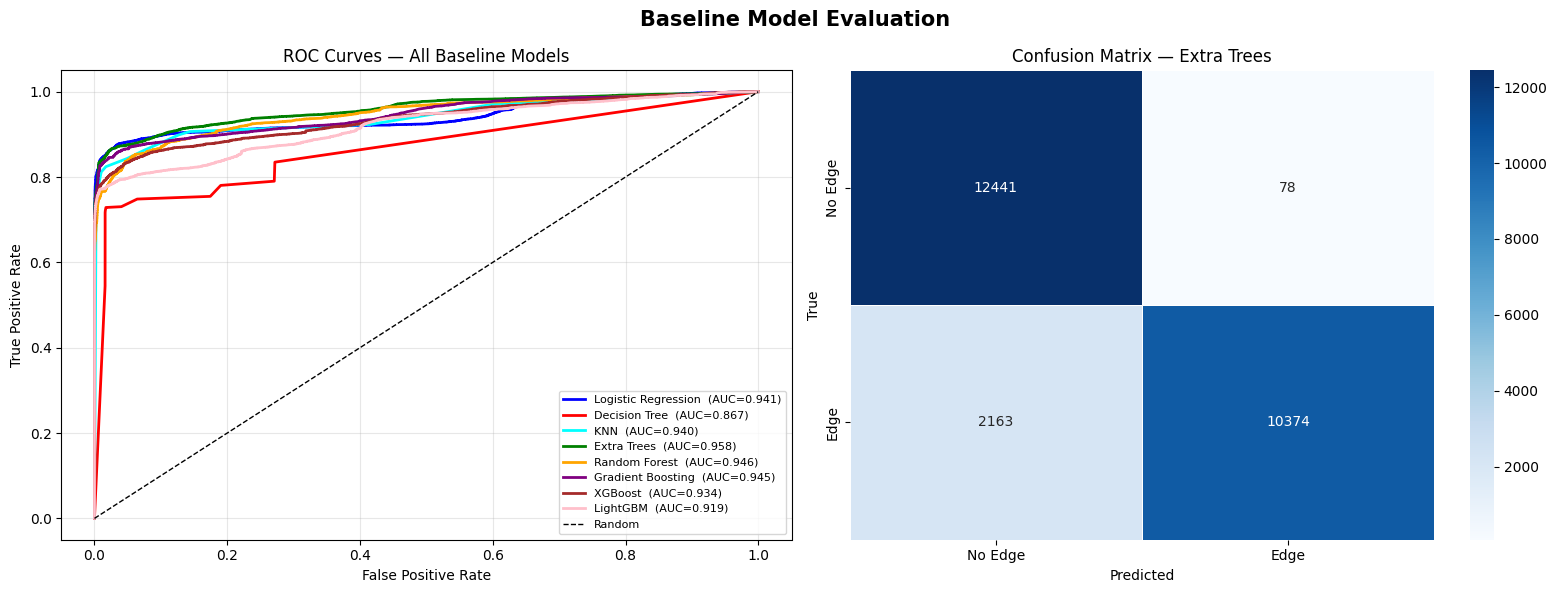

Best baseline model by ROC-AUC : Extra Trees


In [23]:
models_info = [
    ('Logistic Regression', lr_prob,   lr_pred),
    ('Decision Tree',       dt_prob,   dt_pred),
    ('KNN',                 knn_prob,  knn_pred),
    ('Extra Trees',         et_prob,   et_pred),
    ('Random Forest',       rf_prob,   rf_pred),
    ('Gradient Boosting',   gb_prob,   gb_pred),
]
if xgb_model:  models_info.append(('XGBoost',  xgb_prob,  xgb_pred))
if lgbm_model: models_info.append(('LightGBM', lgbm_prob, lgbm_pred))

PALETTE = ['blue', 'red', 'cyan', 'green', 'orange', 'purple', 'brown', 'pink']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, prob, _), colour in zip(models_info, PALETTE):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, lw=2, color=colour, label=f'{name}  (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curves — All Baseline Models')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

best_name, best_prob, best_pred = max(
    models_info, key=lambda x: roc_auc_score(y_test, x[1])
)
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Edge', 'Edge'], yticklabels=['No Edge', 'Edge'],
            linewidths=0.5)
axes[1].set(xlabel='Predicted', ylabel='True',
            title=f'Confusion Matrix — {best_name}')

plt.suptitle('Baseline Model Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/roc_and_cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best baseline model by ROC-AUC : {best_name}')

## 9. Feature Importance

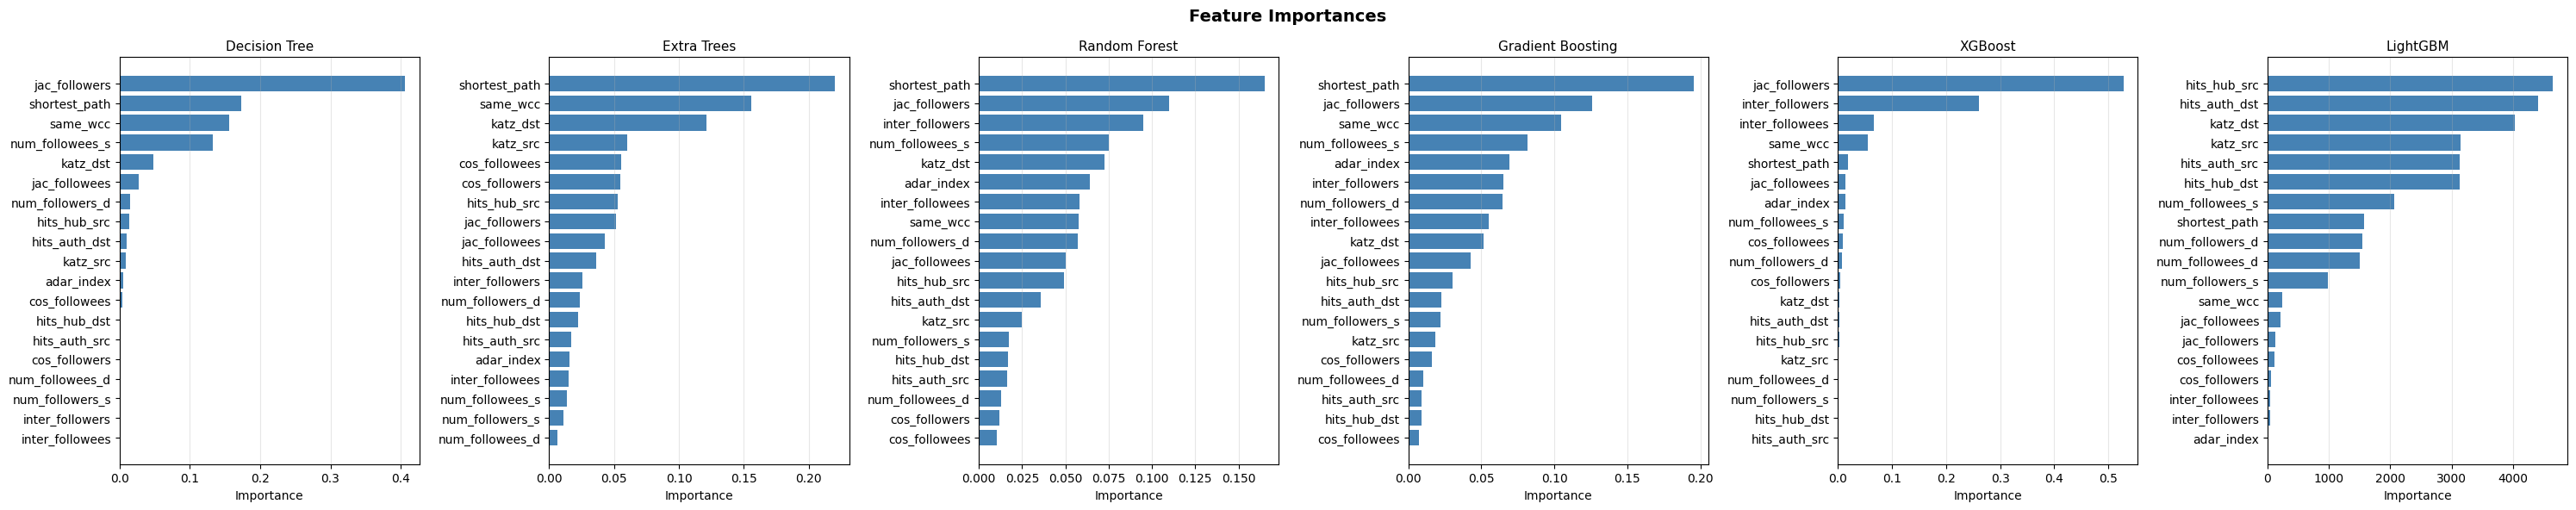

In [24]:
tree_models = [
    (name, m) for name, m in [
        ('Decision Tree',   dt_model),
        ('Extra Trees',     et_model),
        ('Random Forest',   rf_model),
        ('Gradient Boosting', gb_model),
    ] + ([('XGBoost', xgb_model)] if xgb_model else [])
      + ([('LightGBM', lgbm_model)] if lgbm_model else [])
    if hasattr(m, 'feature_importances_')
]

n_models = len(tree_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models):
    importances = model.feature_importances_
    order = importances.argsort()[::-1]
    feat_names = [FEATURE_COLS[i] for i in order]
    ax.barh(feat_names[::-1], importances[order][::-1], color='steelblue')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison Summary

                         F1  Precision  Recall  ROC-AUC  PR-AUC
Model                                                          
Extra Trees          0.9025     0.9925  0.8275   0.9581  0.9698
Random Forest        0.8742     0.9678  0.7971   0.9465  0.9603
Gradient Boosting    0.9011     0.9893  0.8274   0.9452  0.9615
Logistic Regression  0.9089     0.9896  0.8405   0.9408  0.9612
KNN                  0.8913     0.9450  0.8433   0.9398  0.9505
XGBoost              0.8845     0.9250  0.8473   0.9341  0.9535
LightGBM             0.8660     0.9676  0.7838   0.9192  0.9421
Decision Tree        0.7921     0.8043  0.7803   0.8669  0.8765

  Top-2 models for tuning: ['Extra Trees', 'Random Forest']


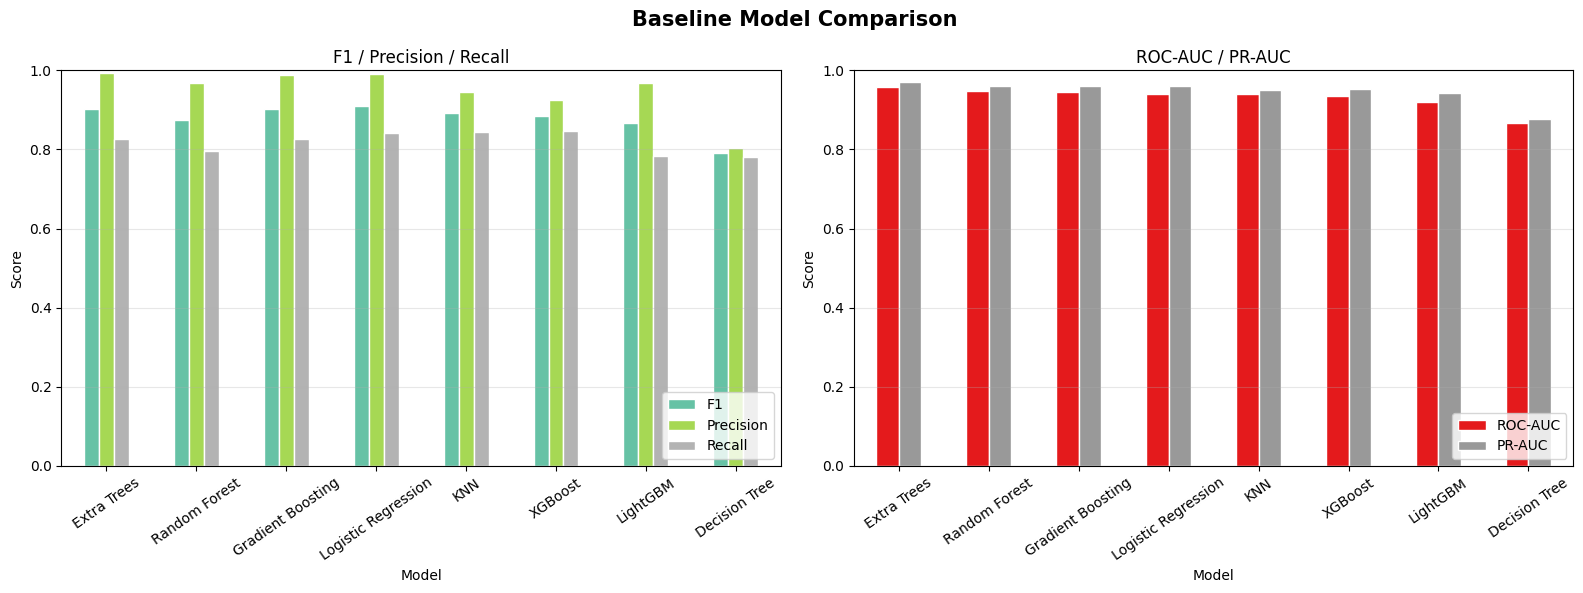

In [25]:
rows = []
for name, prob, pred in models_info:
    rows.append({
        'Model':     name,
        'F1':        round(f1_score(y_test, pred),                4),
        'Precision': round(precision_score(y_test, pred),         4),
        'Recall':    round(recall_score(y_test, pred),            4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),           4),
        'PR-AUC':    round(average_precision_score(y_test, prob), 4),
    })

summary_df = (
    pd.DataFrame(rows)
      .set_index('Model')
      .sort_values('ROC-AUC', ascending=False)
)

print(summary_df.to_string())

top2_names = summary_df.index[:2].tolist()
print(f'\n  Top-2 models for tuning: {top2_names}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_df[['F1', 'Precision', 'Recall']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='white'
)
axes[0].set(title='F1 / Precision / Recall', ylabel='Score', ylim=(0, 1))
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

summary_df[['ROC-AUC', 'PR-AUC']].plot(
    kind='bar', ax=axes[1], colormap='Set1', edgecolor='white'
)
axes[1].set(title='ROC-AUC / PR-AUC', ylabel='Score', ylim=(0, 1))
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Baseline Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Hyperparameter Tuning (Top-2 Models)

`RandomizedSearchCV` on the **two best** baseline models (by ROC-AUC).

**Fix applied:** `clone(base_model)` is used instead of passing the already-fitted
estimator directly. This guarantees each search starts from a clean, unfitted state.

In [26]:
%%time

_model_map = {
    'Logistic Regression' : lr_pipeline,
    'Decision Tree'       : dt_model,
    'KNN'                 : knn_pipeline,
    'Extra Trees'         : et_model,
    'Random Forest'       : rf_model,
    'Gradient Boosting'   : gb_model,
}
if xgb_model:  _model_map['XGBoost']  = xgb_model
if lgbm_model: _model_map['LightGBM'] = lgbm_model

_param_grids = {
    'XGBClassifier': {
        'n_estimators':     [300, 500, 700],
        'max_depth':        [4, 6, 8],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [3, 5, 7],
        'reg_alpha':        [0.0, 0.1, 0.5],
        'reg_lambda':       [0.5, 1.0, 2.0],
    },
    'LGBMClassifier': {
        'n_estimators':     [300, 500, 700],
        'max_depth':        [-1, 10, 20],
        'learning_rate':    [0.01, 0.05, 0.1],
        'num_leaves':       [63, 127, 255],
        'min_child_samples':[10, 20, 30],
        'subsample':        [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'reg_alpha':        [0.0, 0.1, 0.5],
        'reg_lambda':       [0.0, 0.1, 0.5],
    },
    'GradientBoostingClassifier': {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [3, 5, 7],
        'learning_rate':     [0.01, 0.05, 0.1],
        'subsample':         [0.7, 0.8, 1.0],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf':  [3, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'RandomForestClassifier': {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [10, 20, None],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf':  [3, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'ExtraTreesClassifier': {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [10, 20, None],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf':  [3, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'DecisionTreeClassifier': {
        'max_depth':         [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf':  [1, 2, 5],
        'max_features':      ['sqrt', 'log2', None],
    },
}

_tuned_models  = {}
_tuned_results = {}

for model_name in top2_names:
    print('\n' + '-' * 60)
    print(f'  Tuning: {model_name}')
    print('-' * 60)

    base_model = _model_map.get(model_name)
    if base_model is None:
        print('  Skipped — model not available.')
        continue

    model_class = type(base_model).__name__
    if model_class == 'Pipeline':
        inner_class = type(base_model.named_steps['clf']).__name__
        raw_grid    = _param_grids.get(inner_class, {})
        param_dist  = {f'clf__{k}': v for k, v in raw_grid.items()}
    else:
        param_dist = _param_grids.get(model_class, {})

    if not param_dist:
        print(f'  No param grid for {model_class} — skipping.')
        continue

    search = RandomizedSearchCV(
        clone(base_model), param_dist,
        n_iter=20, cv=3, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=1,
    )
    search.fit(X_train, y_train)

    print(f'\n  Best params : {search.best_params_}')
    print(f'  CV ROC-AUC  : {search.best_score_:.4f}')

    tuned = search.best_estimator_
    t_pred, t_prob = evaluate_model(
        f'{model_name} (tuned)', tuned, X_train, y_train, X_test, y_test
    )

    _tuned_models[model_name]  = tuned
    _tuned_results[model_name] = (t_pred, t_prob)

print('\n Hyperparameter tuning complete.')


------------------------------------------------------------
  Tuning: Extra Trees
------------------------------------------------------------
Fitting 3 folds for each of 20 candidates, totalling 60 fits

  Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None}
  CV ROC-AUC  : 0.9906
  Extra Trees (tuned)
  Metric             Train      Test
  --------------  --------  --------
  F1                0.9645    0.9051
  Precision         0.9840    0.9843
  Recall            0.9457    0.8377
  ROC-AUC                     0.9580
  PR-AUC                      0.9695

              precision    recall  f1-score   support

     No Edge       0.86      0.99      0.92     12519
        Edge       0.98      0.84      0.91     12537

    accuracy                           0.91     25056
   macro avg       0.92      0.91      0.91     25056
weighted avg       0.92      0.91      0.91     25056


--------------------------------

## 12. ROC Curve Comparison — Baseline vs Tuned

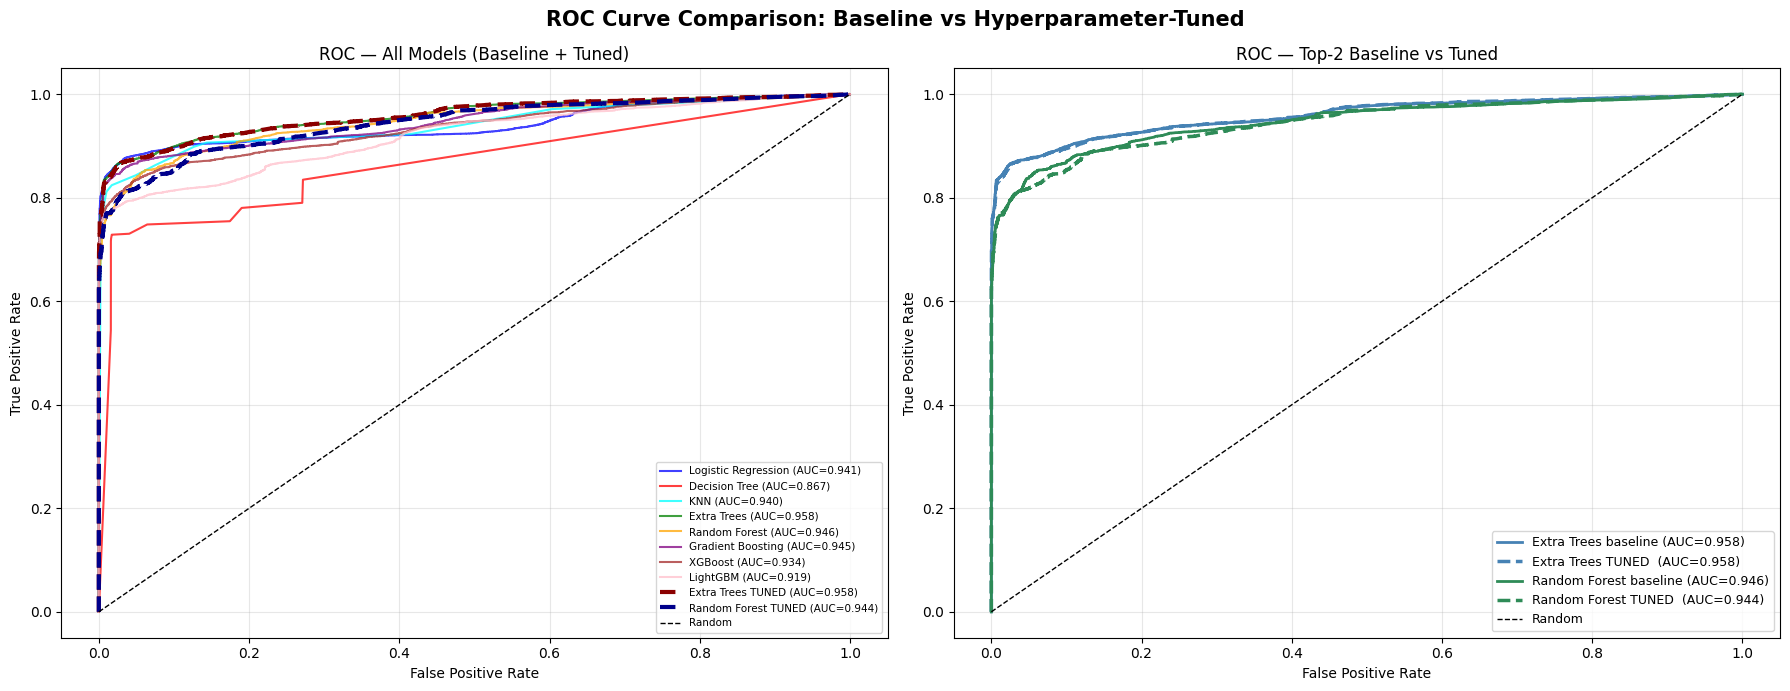

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

BASELINE_PALETTE = ['blue', 'red', 'cyan', 'green', 'orange', 'purple', 'brown', 'pink']
TUNED_PALETTE    = ['darkred', 'darkblue']

for (name, prob, _), colour in zip(models_info, BASELINE_PALETTE):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, lw=1.5, color=colour, alpha=0.75,
                 label=f'{name} (AUC={auc:.3f})')

for model_name, colour in zip(top2_names, TUNED_PALETTE):
    if model_name in _tuned_results:
        _, t_prob = _tuned_results[model_name]
        fpr, tpr, _ = roc_curve(y_test, t_prob)
        auc = roc_auc_score(y_test, t_prob)
        axes[0].plot(fpr, tpr, lw=3, color=colour, linestyle='--',
                     label=f'{model_name} TUNED (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC — All Models (Baseline + Tuned)')
axes[0].legend(fontsize=7.5, loc='lower right')
axes[0].grid(alpha=0.3)

for model_name, colour in zip(top2_names, ['steelblue', 'seagreen']):
    _, base_prob, _ = next(x for x in models_info if x[0] == model_name)
    fpr, tpr, _ = roc_curve(y_test, base_prob)
    auc = roc_auc_score(y_test, base_prob)
    axes[1].plot(fpr, tpr, lw=2, color=colour, linestyle='-',
                 label=f'{model_name} baseline (AUC={auc:.3f})')
    if model_name in _tuned_results:
        _, t_prob = _tuned_results[model_name]
        fpr, tpr, _ = roc_curve(y_test, t_prob)
        auc = roc_auc_score(y_test, t_prob)
        axes[1].plot(fpr, tpr, lw=2.5, color=colour, linestyle='--',
                     label=f'{model_name} TUNED  (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC — Top-2 Baseline vs Tuned')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison: Baseline vs Hyperparameter-Tuned',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/roc_comparison_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Build complete leaderboard AFTER tuned results are available.
all_rows = list(rows)

for model_name in top2_names:
    if model_name in _tuned_results:
        t_pred, t_prob = _tuned_results[model_name]
        all_rows.append({
            'Model':     f'{model_name} (tuned)',
            'F1':        round(f1_score(y_test, t_pred),                4),
            'Precision': round(precision_score(y_test, t_pred),         4),
            'Recall':    round(recall_score(y_test, t_pred),            4),
            'ROC-AUC':   round(roc_auc_score(y_test, t_prob),           4),
            'PR-AUC':    round(average_precision_score(y_test, t_prob), 4),
        })

full_summary = (
    pd.DataFrame(all_rows)
      .set_index('Model')
      .sort_values('ROC-AUC', ascending=False)
)
print('Complete model leaderboard (baseline + tuned):')
print(full_summary.to_string())

best_overall_name = full_summary.index[0]
print(f'\n  Overall best model: {best_overall_name}')

Complete model leaderboard (baseline + tuned):
                           F1  Precision  Recall  ROC-AUC  PR-AUC
Model                                                            
Extra Trees            0.9025     0.9925  0.8275   0.9581  0.9698
Extra Trees (tuned)    0.9051     0.9843  0.8377   0.9580  0.9695
Random Forest          0.8742     0.9678  0.7971   0.9465  0.9603
Gradient Boosting      0.9011     0.9893  0.8274   0.9452  0.9615
Random Forest (tuned)  0.8756     0.9659  0.8007   0.9439  0.9580
Logistic Regression    0.9089     0.9896  0.8405   0.9408  0.9612
KNN                    0.8913     0.9450  0.8433   0.9398  0.9505
XGBoost                0.8845     0.9250  0.8473   0.9341  0.9535
LightGBM               0.8660     0.9676  0.7838   0.9192  0.9421
Decision Tree          0.7921     0.8043  0.7803   0.8669  0.8765

  Overall best model: Extra Trees


## 13. Save Models

In [29]:
os.makedirs('data', exist_ok=True)

save_list = [
    ('logistic_regression', lr_pipeline),
    ('decision_tree',       dt_model),
    ('knn',                 knn_pipeline),
    ('extra_trees',         et_model),
    ('random_forest',       rf_model),
    ('gradient_boosting',   gb_model),
]
if xgb_model:  save_list.append(('xgboost',  xgb_model))
if lgbm_model: save_list.append(('lightgbm', lgbm_model))

for model_name, tuned_mdl in _tuned_models.items():
    key = model_name.lower().replace(' ', '_')
    save_list.append((f'tuned_{key}', tuned_mdl))

for name, mdl in save_list:
    path = f'data/model_{name}.pkl'
    joblib.dump(mdl, path)
    kb = os.path.getsize(path) / 1024
    print(f'  {path:<50}  {kb:,.1f} KB')

# Resolve best model object
best_overall_name = full_summary['ROC-AUC'].idxmax()
if best_overall_name.endswith('(tuned)'):
    base = best_overall_name.replace(' (tuned)', '')
    best_model_obj = _tuned_models.get(base)
else:
    best_model_obj = _model_map.get(best_overall_name)

if best_model_obj is not None:
    joblib.dump(best_model_obj, 'data/best_model.pkl')
    print(f'\n  Best model saved: {best_overall_name} → data/best_model.pkl')

# Save all deployment artifacts
with open('data/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

with open('data/graph.pkl', 'wb') as f:
    pickle.dump(train_graph, f)

with open('data/wcc.pkl', 'wb') as f:
    pickle.dump(wcc, f)

artifacts = {
    'mean_katz' : mean_katz,
    'mean_hub'  : mean_hub,
    'mean_auth' : mean_auth,
}
with open('data/artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('\n  All models and deployment artifacts saved.')
print('  Files: best_model.pkl, graph.pkl, wcc.pkl, artifacts.pkl, feature_cols.pkl')

  data/model_logistic_regression.pkl                  1.9 KB
  data/model_decision_tree.pkl                        22.4 KB
  data/model_knn.pkl                                  15,601.4 KB
  data/model_extra_trees.pkl                          66,018.3 KB
  data/model_random_forest.pkl                        82,379.0 KB
  data/model_gradient_boosting.pkl                    1,361.8 KB
  data/model_xgboost.pkl                              1,189.6 KB
  data/model_lightgbm.pkl                             3,363.3 KB
  data/model_tuned_extra_trees.pkl                    180,435.7 KB
  data/model_tuned_random_forest.pkl                  133,440.9 KB

  Best model saved: Extra Trees → data/best_model.pkl

  All models and deployment artifacts saved.
  Files: best_model.pkl, graph.pkl, wcc.pkl, artifacts.pkl, feature_cols.pkl


## 14. Inference

`LinkPredictor` assembles all features on-the-fly for a single `(source, destination)` pair.

**Fixes applied:**
- Feature assembly now uses `self.feature_cols` to index `feat_dict` by name —
  order is explicit and drift-proof.
- `is_following_back` removed from the features list (leakage prevention).
- No globals; safe in FastAPI / Flask / any production context.

In [30]:
class LinkPredictor:
    """
    Self-contained predictor. Load once at startup, call predict() per request.
    Applies rank-based normalization on centrality features — same as training.
    """

    RANK_COLS = ['katz_src', 'katz_dst',
                 'hits_hub_src', 'hits_hub_dst',
                 'hits_auth_src', 'hits_auth_dst']

    def __init__(self, model, graph, wcc, node_to_wcc_id, katz, hits_hub, hits_auth,
                 mean_katz, mean_hub, mean_auth, feature_cols, rank_bounds):
        self.model           = model
        self.graph           = graph
        self.wcc             = wcc
        self.node_to_wcc_id  = node_to_wcc_id
        self.katz         = katz
        self.hits_hub     = hits_hub
        self.hits_auth    = hits_auth
        self.mean_katz    = mean_katz
        self.mean_hub     = mean_hub
        self.mean_auth    = mean_auth
        self.feature_cols = feature_cols
        self.rank_bounds  = rank_bounds   # {col: (min_train, max_train)}

    def _rank_normalize(self, col, value):
        """Apply same min-max normalization used during training."""
        mn, mx = self.rank_bounds[col]
        span = mx - mn if mx != mn else 1.0
        return float(np.clip((value - mn) / span, 0, 1))

    def predict(self, source_node, destination_node, threshold=0.5):
        src, dst = source_node, destination_node

        src_known = self.graph.has_node(src)
        dst_known = self.graph.has_node(dst)
        warning = None
        if not src_known and not dst_known:
            warning = f'Both nodes {src} and {dst} are unseen — features will be zero'
        elif not src_known:
            warning = f'Source node {src} not in training graph — some features will be zero'
        elif not dst_known:
            warning = f'Destination node {dst} not in training graph — some features will be zero'

        s_in  = set(self.graph.predecessors(src)) if src_known else set()
        s_out = set(self.graph.successors(src))   if src_known else set()
        d_in  = set(self.graph.predecessors(dst)) if dst_known else set()
        d_out = set(self.graph.successors(dst))   if dst_known else set()

        feat_dict = {
            'jac_followers':   jaccard_for_followers(self.graph, src, dst),
            'jac_followees':   jaccard_for_followees(self.graph, src, dst),
            'cos_followers':   cosine_distance_for_followers(self.graph, src, dst),
            'cos_followees':   cosine_distance_for_followees(self.graph, src, dst),
            'num_followers_s': len(s_in),
            'num_followees_s': len(s_out),
            'num_followers_d': len(d_in),
            'num_followees_d': len(d_out),
            'inter_followers': len(s_in & d_in),
            'inter_followees': len(s_out & d_out),
            'shortest_path':   compute_shortest_path_length(self.graph, src, dst),
            'same_wcc':        belongs_to_same_wcc(self.graph, self.wcc, self.node_to_wcc_id, src, dst),
            'adar_index':      calc_adar_in(self.graph, src, dst),
            'katz_src':        self.katz.get(src, self.mean_katz),
            'katz_dst':        self.katz.get(dst, self.mean_katz),
            'hits_hub_src':    self.hits_hub.get(src, self.mean_hub),
            'hits_hub_dst':    self.hits_hub.get(dst, self.mean_hub),
            'hits_auth_src':   self.hits_auth.get(src, self.mean_auth),
            'hits_auth_dst':   self.hits_auth.get(dst, self.mean_auth),
        }

        # Apply same rank normalization used during training
        for col in self.RANK_COLS:
            feat_dict[col] = self._rank_normalize(col, feat_dict[col])

        features = [feat_dict[col] for col in self.feature_cols]
        prob = self.model.predict_proba([features])[0][1]
        pred = int(prob >= threshold)

        import logging as _log
        _log.info('LinkPredictor | src=%s dst=%s prob=%.4f pred=%s',
                  src, dst, prob, 'LINK' if pred else 'NO LINK')
        if warning:
            _log.warning('LinkPredictor | %s', warning)
        # Also print for notebook convenience
        print(f'  Source      : {src}')
        print(f'  Destination : {dst}')
        print(f'  Probability : {prob:.4f}')
        print(f'  Prediction  : {"LINK EXISTS" if pred else "NO LINK EXPECTED"}')
        if warning:
            print(f'  WARNING     : {warning}')
        return {'probability': prob, 'prediction': pred, 'warning': warning}


In [31]:
# Best model already resolved in Section 13; reuse here.
# _best_name and _best_model_obj are set above — no need to recompute.
_best_name = full_summary['ROC-AUC'].idxmax()  # idempotent; safe to repeat
_base_name = _best_name.replace(' (tuned)', '')

if _best_name.endswith('(tuned)'):
    _best_model_obj = _tuned_models.get(_base_name)
else:
    _best_model_obj = _model_map.get(_best_name)

if _best_model_obj is None:
    raise RuntimeError(f'Could not resolve best model object for: {_best_name}')

print(f'Using best model: {_best_name}')

predictor = LinkPredictor(
    model           = _best_model_obj,
    graph           = train_graph,
    wcc             = wcc,
    node_to_wcc_id  = node_to_wcc_id,
    katz            = katz,
    hits_hub     = hits_hub,
    hits_auth    = hits_auth,
    mean_katz    = mean_katz,
    mean_hub     = mean_hub,
    mean_auth    = mean_auth,
    feature_cols = FEATURE_COLS,
    rank_bounds  = _rank_bounds,   # pass normalization bounds for inference
)

joblib.dump(predictor, 'data/predictor.pkl')
print('LinkPredictor saved to data/predictor.pkl')

Using best model: Extra Trees
LinkPredictor saved to data/predictor.pkl


In [32]:
print('--- Example 1: known connected pair ---')
_ = predictor.predict(273084, 1505602)

print()
print('--- Example 2: likely unconnected pair ---')
_ = predictor.predict(669354, 1635354)

--- Example 1: known connected pair ---
  Source      : 273084
  Destination : 1505602
  Probability : 0.6020
  Prediction  : LINK EXISTS

--- Example 2: likely unconnected pair ---
  Source      : 669354
  Destination : 1635354
  Probability : 0.1927
  Prediction  : NO LINK EXPECTED
